## Practise - Simulator Training

### practise I: Temperature Curve
The Huygens probe sent temperature data during descent. Plot a simple chart so we can see how the temperature changes over time.

**Assignment:**
- we will use data from Titan:

    ```python
    time_log = np.arange(1, 61)
    data_titan = {
        'minute': time_log,
        'surface_temp_c': np.random.uniform(-181, -178, 60),
        'wind_speed_kmh': np.linspace(120, 5, 60) + np.random.normal(0, 5, 60),
        'methane_lake_level_m': np.random.uniform(50, 52, 60)
    }

    df_titan = pd.DataFrame(data_titan)
    ```

- Plot the temperature `surface_temp_c` dependent on time (minute) using a line chart.
- Set the line color to blue and add a grid.
- Name the axes and the chart.

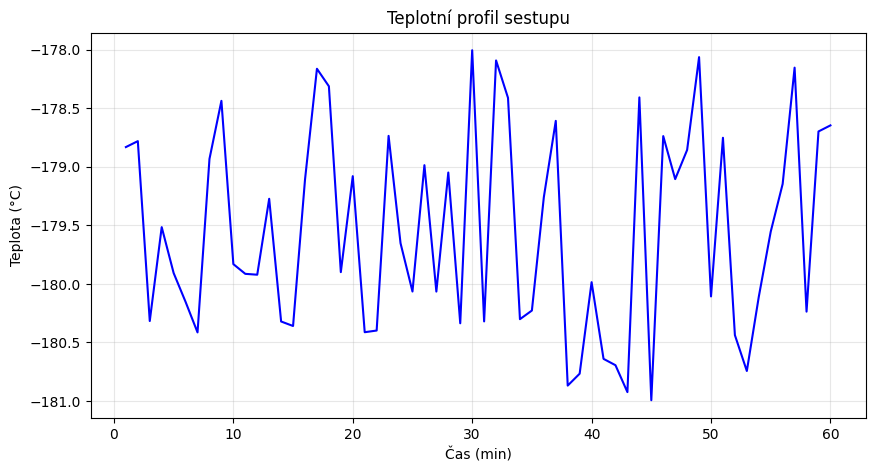

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

time_log = np.arange(1, 61) 
data_titan = {
    'minute': time_log,
    'surface_temp_c': np.random.uniform(-181, -178, 60), 
    'wind_speed_kmh': np.linspace(120, 5, 60) + np.random.normal(0, 5, 60), 
    'methane_lake_level_m': np.random.uniform(50, 52, 60) 
}

df_titan = pd.DataFrame(data_titan)

# 1. fig and ax objects
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Plotting
ax.plot(df_titan['minute'], df_titan['surface_temp_c'], color='blue', label='Temperature (°C)', linewidth=2)

# 3. Modifications
ax.set_title("Temperature Profile During Descent")
ax.set_xlabel("Time (min)")
ax.set_ylabel("Temperature (°C)")
ax.grid(True, alpha=0.3) # light grid
ax.legend()

plt.show()

## practise II: Lake Levels
Radar measured the depth of the three largest methane lakes on Titan. We will compare them graphically.

**Assignment:**

- we will use data from Titan:

    ```python
    lakes = ['Kraken Mare', 'Ligeia Mare', 'Punga Mare']
    depths = [160, 170, 120] # in meters
    ```

- Plot a bar chart.
- Represent each column with a different color.

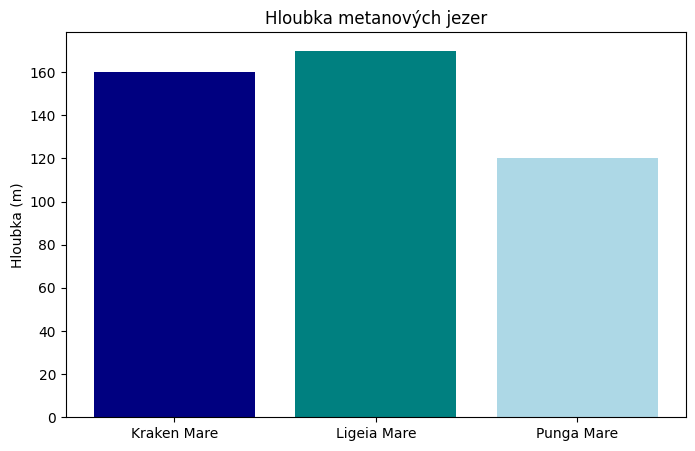

In [ ]:
# Data
lakes = ['Kraken Mare', 'Ligeia Mare', 'Punga Mare']
depths = [160, 170, 120] # v metrech

# 1. fig and ax objects
fig, ax = plt.subplots(figsize=(8, 5))

# 2. Plotting
# color=['navy', 'teal', 'lightblue']
ax.bar(lakes, depths, color=['#000080', '#008080', '#ADD8E6'])

# 3. Modifications
ax.set_title("Depth of Methane Lakes")
ax.set_ylabel("Depth (m)")

plt.show()

## Homework (Project: Mars)
In the previous phase (last lesson), we analyzed data about the base environment.

**Mission:** Now we must turn these numbers into clear charts for commanding officers so they can decide on the safety of extravehicular activities (EVA).

0. Input Data: Run the following cell. It will load (simulate) already processed data from the previous mission phase for you.

### Data State Reconstruction from Previous Lesson
```python
# --- DATA PREPARATION (run first) ---
import pandas as pd
import numpy as np

dates = pd.date_range(start='2035-01-01', periods=100, freq='D')
data = {
    'date': dates,
    'avg_temp_c': np.random.uniform(-80, -20, 100),
    'pressure_pa': np.random.uniform(600, 650, 100),
    'radiation_rem': np.random.uniform(0.1, 0.5, 100) + np.sin(np.linspace(0, 10, 100)) * 0.1, # Sine wave added for a nicer chart
    'solar_flare': np.random.choice([True, False], 100, p=[0.15, 0.85])
}
df_mars_processed = pd.DataFrame(data)

# Calculating rolling average
df_mars_processed['radiation_trend'] = df_mars_processed['radiation_rem'].rolling(window=7).mean()

print("Phase 2 data loaded.")
print(df_mars_processed.head())
```

### Assignment:

We will use the prepared DataFrame `df_mars_processed`.

- Chart 1: Radiation Situation (Line Plot):

    - Create a chart (fig, ax) that displays radiation development over time.

    - Plot raw radiation `radiation_rem` as a thin, semi-transparent line (e.g., gray, alpha=0.5).

    - In the same chart, plot the trend `radiation_trend` as a distinct (thicker) red line.

    - Add a grid, axis labels, and a legend.

- Chart 2: Atmospheric Analysis (Scatter Plot):

    - Verify if a visual relationship exists between pressure and temperature.

    - Create a scatter plot where `pressure_pa` is on the X-axis and `avg_temp_c` temperature is on the Y-axis.

    - Set the dot color to dark blue and slight transparency.

- Export:

    - Save the chart with radiation using code as image `mars_radiation_status.png`.

Phase 2 data loaded.
        date  avg_temp_c  pressure_pa  radiation_rem  solar_flare  \
0 2035-01-01  -57.582992   604.815403       0.155574         True   
1 2035-01-02  -69.974960   621.768135       0.474167        False   
2 2035-01-03  -32.555790   619.642505       0.151126        False   
3 2035-01-04  -58.021729   623.315749       0.141844         True   
4 2035-01-05  -46.058694   601.017405       0.415477        False   

   radiation_trend  
0              NaN  
1              NaN  
2              NaN  
3              NaN  
4              NaN  


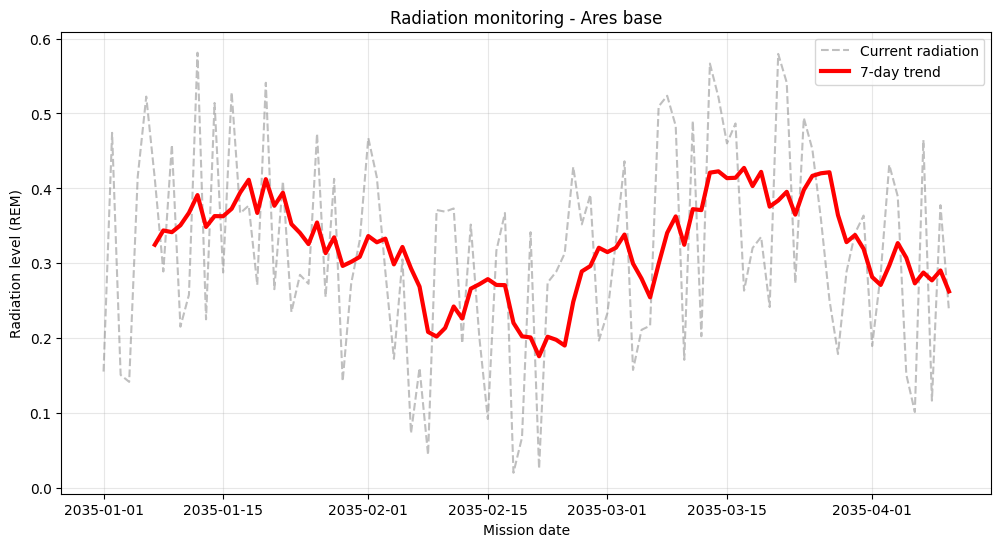

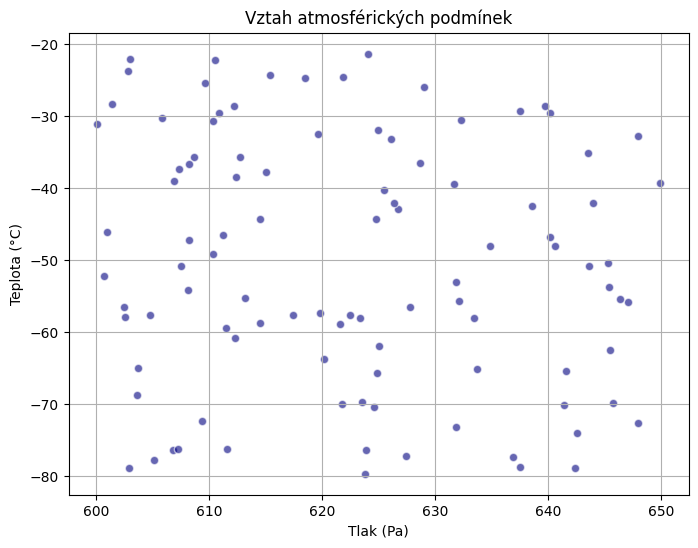

In [ ]:
import pandas as pd
import numpy as np

# Data reconstruction
dates = pd.date_range(start='2035-01-01', periods=100, freq='D')
data = {
    'date': dates,
    'avg_temp_c': np.random.uniform(-80, -20, 100),
    'pressure_pa': np.random.uniform(600, 650, 100),
    'radiation_rem': np.random.uniform(0.1, 0.5, 100) + np.sin(np.linspace(0, 10, 100)) * 0.1,
    'solar_flare': np.random.choice([True, False], 100, p=[0.15, 0.85])
}
df_mars_processed = pd.DataFrame(data)

df_mars_processed['radiation_trend'] = df_mars_processed['radiation_rem'].rolling(window=7).mean()

print("Phase 2 data loaded.")
print(df_mars_processed.head())

# --- 1: Radiation Report ---
fig, ax = plt.subplots(figsize=(12, 6))

# 1. Raw data
# alpha=0.5 (opacity)
ax.plot(df_mars_processed['date'], df_mars_processed['radiation_rem'], 
        color='grey', linestyle='--', alpha=0.5, label='Current radiation')

# 2. 7-day trend
ax.plot(df_mars_processed['date'], df_mars_processed['radiation_trend'], 
        color='red', linewidth=3, label='7-day trend')

# 3. Settings
ax.set_title("Radiation monitoring - Ares base")
ax.set_ylabel("Radiation level (REM)")
ax.set_xlabel("Mission date")
ax.grid(True, alpha=0.3)
ax.legend()

# 4. Export
fig.savefig('mars_radiation_status.png')

plt.show()


# --- 2: Corelation Pressure / Temperature ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(df_mars_processed['pressure_pa'], df_mars_processed['avg_temp_c'], 
           color='navy', alpha=0.6, edgecolors='white')

ax.set_title("Atmosphere conditions corelation")
ax.set_xlabel("Pressure (Pa)")
ax.set_ylabel("Temperature (°C)")
ax.grid(True)

plt.show()

---
#### © Jiří Svoboda (George Freedom)
- Web: https://GeorgeFreedom.com
- LinkedIn: https://www.linkedin.com/in/georgefreedom/
- Let's talk: https://cal.com/georgefreedom